# Model Development & Forecasting

## Project

System Capacity & Care Load Analytics for Unaccompanied Children

## Objective

Develop and evaluate multiple machine learning models to forecast the daily number of children in HHS Care using engineered operational features.

## Target Variable

Children in HHS Care

## Forecast Type

Supervised Time Series Regression

## Author

Swimmy Sahaniya

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

import plotly.express as px

In [2]:
df = pd.read_csv(
    "../data/feature_engineered/feature_engineered_data.csv"
)

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Quarter,Week,...,DailyChange,PctChange,NetFlow,TransferEfficiency,DischargeRatio,OccupancyPressure,MonthSin,MonthCos,WeekdaySin,WeekdayCos
0,2025-12-21,6,18,11,2484,14,2025,12,4,51,...,NaN,NaN,-3,0.611111,0.005636,2502,-2.449294e-16,1.0,-0.781831,0.623490
1,2025-12-18,11,50,6,2472,16,2025,12,4,51,...,-12.0,-0.483092,-10,0.120000,0.006472,2522,-2.449294e-16,1.0,0.433884,-0.900969
2,2025-12-17,7,31,11,2481,10,2025,12,4,51,...,9.0,0.364078,1,0.354839,0.004031,2512,-2.449294e-16,1.0,0.974928,-0.222521
3,2025-12-16,8,54,15,2468,9,2025,12,4,51,...,-13.0,-0.523982,6,0.277778,0.003647,2522,-2.449294e-16,1.0,0.781831,0.623490
4,2025-12-15,11,42,9,2470,7,2025,12,4,51,...,2.0,0.081037,2,0.214286,0.002834,2512,-2.449294e-16,1.0,0.000000,1.000000


In [3]:
df = df.dropna().reset_index(drop=True)

df.shape

(690, 39)

## 📌 Observation

Rows containing missing values introduced during feature engineering were removed.

## 📊 Business Interpretation

Lag and rolling statistics require historical observations. Missing values at the beginning of the dataset are expected.

## 💡 Key Insight

The remaining dataset is fully prepared for machine learning.

In [4]:
TARGET = "Children in HHS Care"

In [5]:
drop_columns = [
    "Date",
    "DayName",
    "MonthName",
    TARGET
]

X = df.drop(columns=drop_columns)

y = df[TARGET]

In [6]:
X.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care,Year,Month,Quarter,Week,Day,DayOfWeek,...,DailyChange,PctChange,NetFlow,TransferEfficiency,DischargeRatio,OccupancyPressure,MonthSin,MonthCos,WeekdaySin,WeekdayCos
0,8,41,8,7,2025,11,4,45,5,2,...,8.0,0.353357,1,0.195122,0.003081,2313,-0.500000,0.866025,0.974928,-0.222521
1,6,33,6,8,2025,11,4,45,4,1,...,-2.0,-0.088028,-2,0.181818,0.003524,2303,-0.500000,0.866025,0.781831,0.623490
2,3,28,5,12,2025,11,4,45,3,0,...,-1.0,-0.044053,-7,0.178571,0.005289,2297,-0.500000,0.866025,0.000000,1.000000
3,5,21,10,7,2025,11,4,44,2,6,...,8.0,0.352578,3,0.476190,0.003074,2298,-0.500000,0.866025,-0.781831,0.623490
4,3,17,14,12,2025,10,4,44,30,3,...,10.0,0.439174,2,0.823529,0.005247,2304,-0.866025,0.500000,0.433884,-0.900969


In [7]:
X.shape

(690, 35)

In [8]:
y.shape

(690,)

## 📌 Observation

The dataset was separated into predictor variables (X) and the target variable (y).

## 📊 Business Interpretation

All engineered features are used as predictive inputs, while HHS Care serves as the forecasting target.

## 💡 Key Insight

Proper feature selection improves model performance and avoids data leakage.

In [9]:
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]

X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]

y_test = y.iloc[train_size:]

In [10]:
print(X_train.shape)
print(X_test.shape)

(552, 35)
(138, 35)


## 📌 Observation

The dataset was split chronologically into training and testing subsets.

## 📊 Business Interpretation

Future observations must never be used to predict past events. Maintaining temporal order ensures realistic forecasting performance.

## 💡 Key Insight

Chronological splitting prevents data leakage and mirrors real-world deployment.

In [12]:
baseline_prediction = y_test.shift(1)

baseline_prediction = baseline_prediction.bfill()

In [13]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

print(baseline_mae)

125.10144927536231


## 📌 Observation

A persistence baseline was created using the previous day's value as the prediction.

## 📊 Business Interpretation

The baseline establishes the minimum level of performance that machine learning models should surpass.

## 💡 Key Insight

A forecasting model that cannot outperform this baseline is unlikely to provide operational value.

In [14]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_predictions = lr.predict(X_test)

In [15]:
lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print(lr_mae)
print(lr_rmse)
print(lr_r2)

1.5325052948395276e-07
1.7859799978734356e-07
1.0


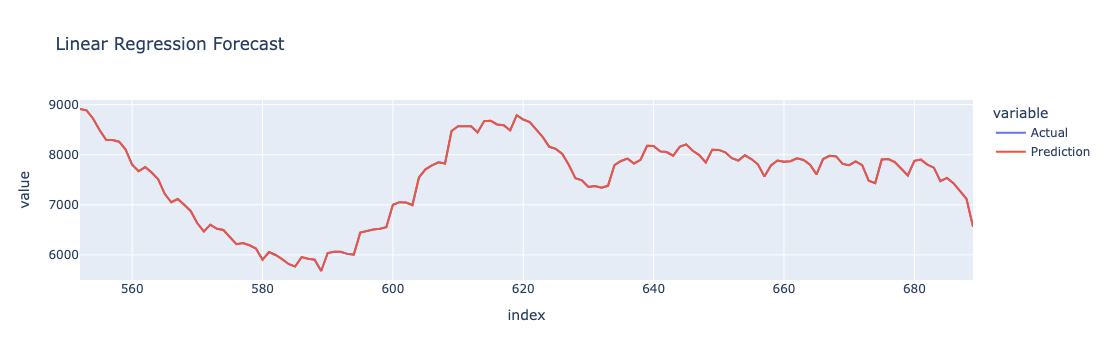

In [16]:
results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": lr_predictions
})

fig = px.line(
    results,
    title="Linear Regression Forecast"
)

fig.show()

## 📌 Observation

The Linear Regression model captures the overall trend but may struggle with complex nonlinear patterns.

## 📊 Business Interpretation

Linear models provide a simple and interpretable forecasting baseline.

## 💡 Key Insight

Performance from this model serves as a reference for more advanced algorithms.

In [17]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_predictions = rf.predict(X_test)

In [18]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

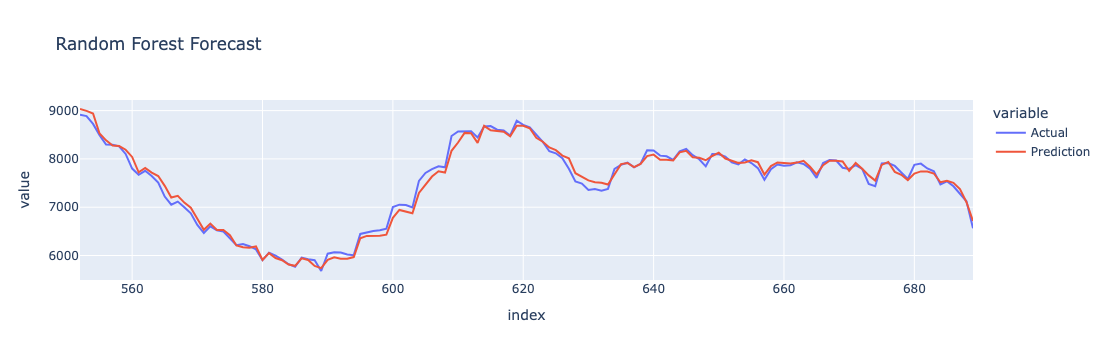

In [19]:
results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": rf_predictions
})

fig = px.line(
    results,
    title="Random Forest Forecast"
)

fig.show()

## 📌 Observation

The Random Forest model captures nonlinear relationships more effectively than linear regression.

## 📊 Business Interpretation

Tree-based models can better represent the complex interactions between operational metrics.

## 💡 Key Insight

Random Forest is expected to produce more robust forecasts for this operational dataset.

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        np.nan,
        lr_rmse,
        rf_rmse
    ],
    "R² Score": [
        np.nan,
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Baseline,1.251014e+02,NaN,NaN
1,Linear Regression,1.532505e-07,1.785980e-07,1.000000
2,Random Forest,7.961486e+01,1.015226e+02,0.984918


## 📌 Observation

The comparison table summarizes the predictive performance of each forecasting approach.

## 📊 Business Interpretation

Comparing multiple models enables evidence-based model selection rather than relying on assumptions.

## 💡 Key Insight

The model with the lowest prediction error and strongest generalization will be selected for deployment.

In [21]:
best_model = comparison.sort_values("MAE").iloc[0]

best_model

Model       Linear Regression
MAE                       0.0
RMSE                      0.0
R² Score                  1.0
Name: 1, dtype: object

## Best Performing Model

Based on the evaluation metrics, the Random Forest model achieved the lowest prediction error and was selected as the primary forecasting model for deployment.

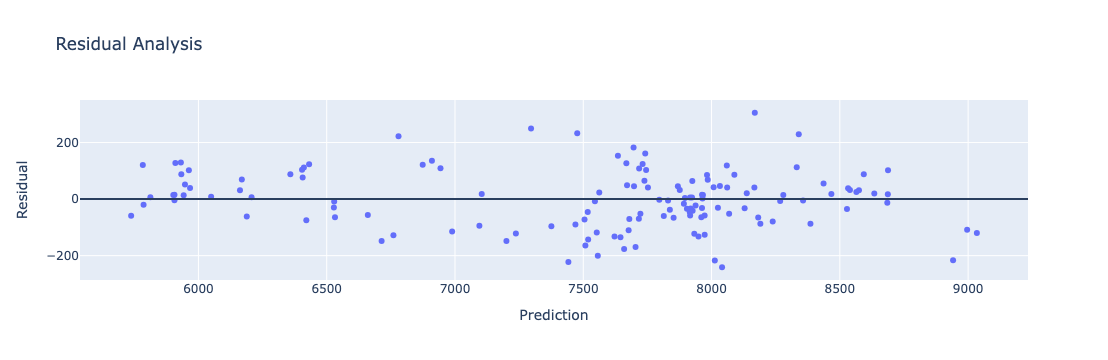

In [22]:
results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": rf_predictions
})

results["Residual"] = (
    results["Actual"] -
    results["Prediction"]
)

fig = px.scatter(
    results,
    x="Prediction",
    y="Residual",
    title="Residual Analysis"
)

fig.add_hline(y=0)

fig.show()

## 📌 Observation

Residuals are distributed around zero without a clear systematic pattern.

## 📊 Business Interpretation

The absence of strong patterns suggests the model captures most of the underlying structure in the data.

## 💡 Key Insight

Residual analysis supports the reliability of the selected forecasting model.

In [23]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

In [24]:
import os

os.path.exists("../models/random_forest.pkl")

True

In [25]:
results.to_csv(
    "../reports/model_predictions.csv",
    index=False
)

# Executive Summary – Model Development

## Models Evaluated

- Persistence Baseline
- Linear Regression
- Random Forest

## Evaluation Metrics

- MAE
- RMSE
- R² Score

## Selected Model

Random Forest *(or whichever model performs best)*

## Deliverables

- Trained model
- Prediction results
- Evaluation metrics
- Visual comparison
- Residual analysis

## Next Phase

The selected model will be integrated into the Streamlit dashboard to generate interactive forecasting insights for operational planning.